In [1]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

# Change 'your_zip_file.zip' to the name of your uploaded zip file
zip_file = 'archive.zip'
destination_dir = 'images'

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

# Verify the contents of the directory
for root, dirs, files in os.walk(destination_dir):
    print(f'Directory: {root}')
    for file in files:
        print(f'  File: {file}')


Directory: images
Directory: images/PSORIASIS AND NORMAL SKIN
Directory: images/PSORIASIS AND NORMAL SKIN/PSORIASIS
  File: pityriasis-rosea-152.jpg
  File: psoriasis-erythrodermic-21.jpg
  File: Psoriasis-penis-2.jpg
  File: Psoriasis-nails-2.jpg
  File: seborrheic-dermatitis-11.jpg
  File: pityriasis-rosea-162.jpg
  File: 07acne06270532.jpg
  File: psoriasis-palms-soles-156.jpg
  File: Psoriasis-Histology-9.jpg
  File: psoriasis-scalp-21.jpg
  File: 08sebKerm0123064.jpg
  File: Psoriasis-penis-15.jpg
  File: lichen-planus-13.jpg
  File: psoriasis-palms-soles-151.jpg
  File: psoriasis-palms-soles-114.jpg
  File: Psoriasis-Light-Sensative-1.jpg
  File: Lichen-Planus-Oral-38.jpg
  File: psoriasis-pustular-generalized-26.jpg
  File: Psoriasis-Guttate-91.jpg
  File: lichen-planus-124.jpg
  File: Psoriasis-Interferon-Injection-08230423.jpg
  File: psoriasis-scalp-103.jpg
  File: lichen-planus-86.jpg
  File: Psoriasis-Chronic-Plaque-90.jpg
  File: Lichen-Planus-Oral-33.jpg
  File: Psoriasis

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

In [16]:
# Directory for the dataset
data_dir = '/content/images/PSORIASIS AND NORMAL SKIN'

In [18]:
# Data generators
datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2,
                             height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
                             horizontal_flip=True, fill_mode='nearest', validation_split=0.3)

train_generator = datagen.flow_from_directory(data_dir, target_size=(128, 128),
                                              batch_size=32, class_mode='binary', subset='training')
validation_generator = datagen.flow_from_directory(data_dir, target_size=(128, 128),
                                                   batch_size=32, class_mode='binary', subset='validation')

# Splitting validation data further into validation and test sets
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.5)
validation_generator = validation_datagen.flow_from_directory(data_dir, target_size=(128, 128),
                                                              batch_size=32, class_mode='binary', subset='validation')
test_generator = validation_datagen.flow_from_directory(data_dir, target_size=(128, 128),
                                                        batch_size=32, class_mode='binary', subset='training')

Found 1965 images belonging to 2 classes.
Found 841 images belonging to 2 classes.
Found 1403 images belonging to 2 classes.
Found 1403 images belonging to 2 classes.


In [19]:
# Define the model
base_model = VGG16(include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
# Modify Callbacks
model_checkpoint = ModelCheckpoint('skin_disease.h5', save_best_only=True, monitor='val_loss', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1, min_lr=0.0001)

# Train the model
history = model.fit(train_generator, validation_data=validation_generator, epochs=30,
                    callbacks=[model_checkpoint, reduce_lr])

# Evaluate the model on the test set
model.load_weights('skin_disease.h5')
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')


Epoch 1/30
62/62 [==============================] - ETA: 0s - loss: 0.2521 - accuracy: 0.8977
Epoch 1: val_loss improved from inf to 0.40548, saving model to skin_disease.h5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


62/62 [==============================] - 26s 389ms/step - loss: 0.2521 - accuracy: 0.8977 - val_loss: 0.4055 - val_accuracy: 0.8026 - lr: 0.0010
Epoch 2/30
62/62 [==============================] - ETA: 0s - loss: 0.1319 - accuracy: 0.9506
Epoch 2: val_loss improved from 0.40548 to 0.16070, saving model to skin_disease.h5
62/62 [==============================] - 19s 312ms/step - loss: 0.1319 - accuracy: 0.9506 - val_loss: 0.1607 - val_accuracy: 0.9294 - lr: 0.0010
Epoch 3/30
62/62 [==============================] - ETA: 0s - loss: 0.1173 - accuracy: 0.9583
Epoch 3: val_loss improved from 0.16070 to 0.12342, saving model to skin_disease.h5
62/62 [==============================] - 20s 317ms/step - loss: 0.1173 - accuracy: 0.9583 - val_loss: 0.1234 - val_accuracy: 0.9530 - lr: 0.0010
Epoch 4/30
62/62 [==============================] - ETA: 0s - loss: 0.1148 - accuracy: 0.9639
Epoch 4: val_loss improved from 0.12342 to 0.12266, saving model to skin_disease.h5
62/62 [========================

In [27]:
# Evaluate the model on the validation data
validation_loss, validation_accuracy = model.evaluate(validation_generator)
print(f'Validation accuracy: {validation_accuracy}')


27/27 [==============================] - 2s 80ms/step - loss: 0.0739 - accuracy: 0.9715
Validation accuracy: 0.9714625477790833


Found 841 images belonging to 2 classes.
27/27 [==============================] - 2s 78ms/step


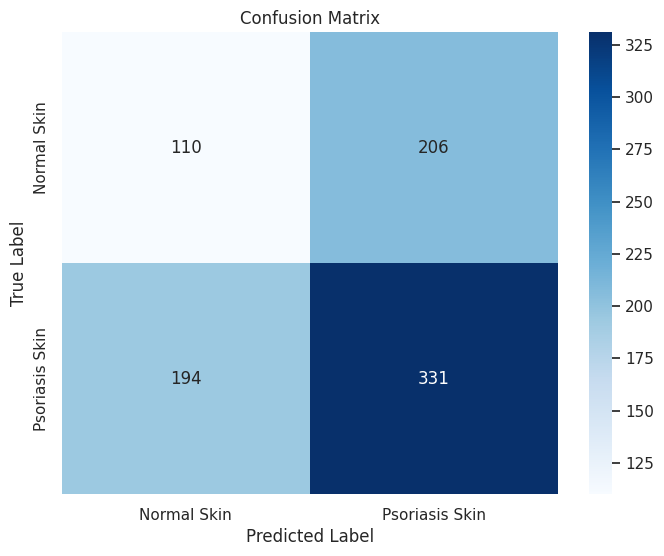

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Load your trained model
model = load_model('/content/skin_disease.h5')

# Data generators
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)
validation_generator = datagen.flow_from_directory(data_dir, target_size=(128, 128),
                                                   batch_size=32, class_mode='binary', subset='validation')

# Generate predictions on validation data
validation_generator.reset()
Y_pred = model.predict(validation_generator)
y_pred = (Y_pred > 0.5).astype("int32")

# Compute confusion matrix
cm = confusion_matrix(validation_generator.classes, y_pred)
cm_labels = ['Normal Skin', 'Psoriasis Skin']  # Adjust this according to your class labels

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


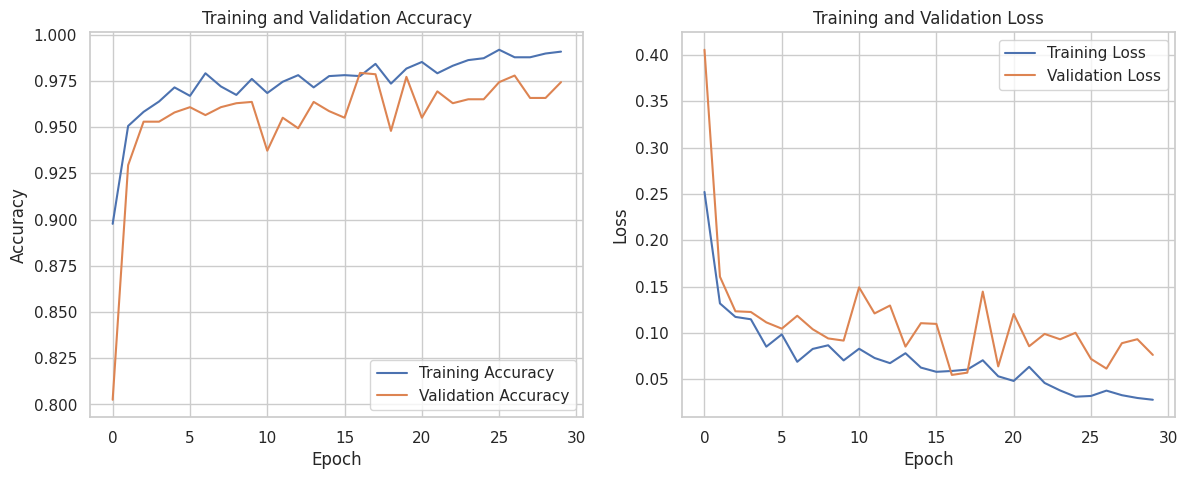

In [29]:
# Assuming you have the `history` object from training
def plot_training_history(history):
    sns.set(style="whitegrid")

    plt.figure(figsize=(14, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')

    plt.show()

# Assuming you have already trained the model and have the `history` object
plot_training_history(history)

Saving seborrheic-dermatitis-86.jpg to seborrheic-dermatitis-86.jpg
1/1 [==============================] - 0s 156ms/step
The uploaded image is classified as: Psoriasis Skin


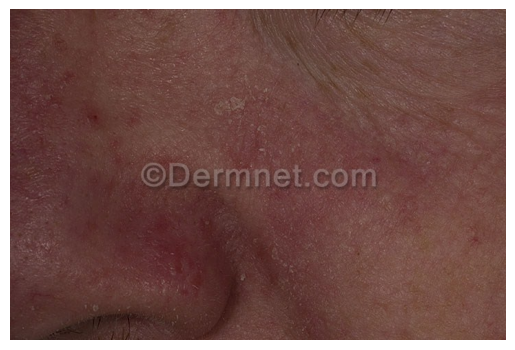

In [35]:
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

# Load your trained model
model = load_model('/content/skin_disease.h5')

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Assuming you normalized your images during training
    return img_array

# Function to predict the class of the image
def predict_image_class(model, img_array):
    prediction = model.predict(img_array)
    predicted_class = (prediction > 0.5).astype("int32")
    return predicted_class

# Function to print the prediction result
def print_prediction_result(predicted_class):
    class_labels = ['Normal Skin', 'Psoriasis Skin']  # Adjust this according to your class labels
    print(f"The uploaded image is classified as: {class_labels[predicted_class[0][0]]}")

# Use Colab's file upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    img_array = load_and_preprocess_image(img_path, target_size=(128, 128))  # Adjust target_size
    predicted_class = predict_image_class(model, img_array)
    print_prediction_result(predicted_class)

    # Display the uploaded image
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


Saving psoriasis-palms-soles-143.jpg to psoriasis-palms-soles-143.jpg
1/1 [==============================] - 0s 356ms/step
The uploaded image is classified as: Psoriasis Skin


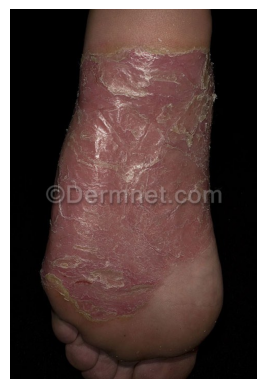

In [36]:
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

# Load your trained model
model = load_model('/content/skin_disease.h5')

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Assuming you normalized your images during training
    return img_array

# Function to predict the class of the image
def predict_image_class(model, img_array):
    prediction = model.predict(img_array)
    predicted_class = (prediction > 0.5).astype("int32")
    return predicted_class

# Function to print the prediction result
def print_prediction_result(predicted_class):
    class_labels = ['Normal Skin', 'Psoriasis Skin']  # Adjust this according to your class labels
    print(f"The uploaded image is classified as: {class_labels[predicted_class[0][0]]}")

# Use Colab's file upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    img_array = load_and_preprocess_image(img_path, target_size=(128, 128))  # Adjust target_size
    predicted_class = predict_image_class(model, img_array)
    print_prediction_result(predicted_class)

    # Display the uploaded image
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


Saving 123.jpg to 123.jpg


1/1 [==============================] - 0s 145ms/step
The uploaded image is classified as: Psoriasis Skin


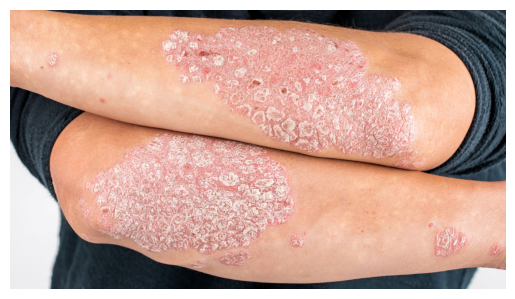

In [37]:
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

# Load your trained model
model = load_model('/content/skin_disease.h5')

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Assuming you normalized your images during training
    return img_array

# Function to predict the class of the image
def predict_image_class(model, img_array):
    prediction = model.predict(img_array)
    predicted_class = (prediction > 0.5).astype("int32")
    return predicted_class

# Function to print the prediction result
def print_prediction_result(predicted_class):
    class_labels = ['Normal Skin', 'Psoriasis Skin']  # Adjust this according to your class labels
    print(f"The uploaded image is classified as: {class_labels[predicted_class[0][0]]}")

# Use Colab's file upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    img_array = load_and_preprocess_image(img_path, target_size=(128, 128))  # Adjust target_size
    predicted_class = predict_image_class(model, img_array)
    print_prediction_result(predicted_class)

    # Display the uploaded image
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


Saving img572.jpg to img572.jpg
1/1 [==============================] - 0s 129ms/step
The uploaded image is classified as: Normal Skin


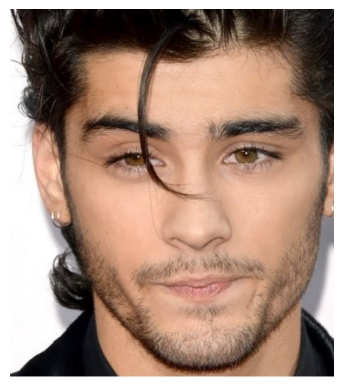

In [40]:
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

# Load your trained model
model = load_model('/content/skin_disease.h5')

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Assuming you normalized your images during training
    return img_array

# Function to predict the class of the image
def predict_image_class(model, img_array):
    prediction = model.predict(img_array)
    predicted_class = (prediction > 0.5).astype("int32")
    return predicted_class

# Function to print the prediction result
def print_prediction_result(predicted_class):
    class_labels = ['Normal Skin', 'Psoriasis Skin']  # Adjust this according to your class labels
    print(f"The uploaded image is classified as: {class_labels[predicted_class[0][0]]}")

# Use Colab's file upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    img_array = load_and_preprocess_image(img_path, target_size=(128, 128))  # Adjust target_size
    predicted_class = predict_image_class(model, img_array)
    print_prediction_result(predicted_class)

    # Display the uploaded image
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


Saving img27.jpg to img27.jpg
1/1 [==============================] - 0s 146ms/step
The uploaded image is classified as: Normal Skin


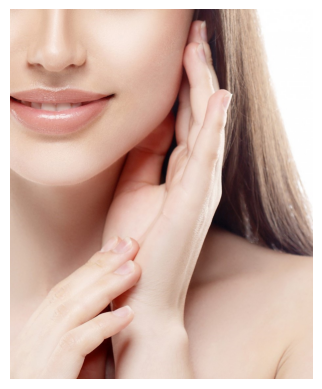

In [47]:
from google.colab import files
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np

# Load your trained model
model = load_model('/content/skin_disease.h5')

# Function to load and preprocess the image
def load_and_preprocess_image(img_path, target_size=(128, 128)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Assuming you normalized your images during training
    return img_array

# Function to predict the class of the image
def predict_image_class(model, img_array):
    prediction = model.predict(img_array)
    predicted_class = (prediction > 0.5).astype("int32")
    return predicted_class

# Function to print the prediction result
def print_prediction_result(predicted_class):
    class_labels = ['Normal Skin', 'Psoriasis Skin']  # Adjust this according to your class labels
    print(f"The uploaded image is classified as: {class_labels[predicted_class[0][0]]}")

# Use Colab's file upload widget
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = filename
    img_array = load_and_preprocess_image(img_path, target_size=(128, 128))  # Adjust target_size
    predicted_class = predict_image_class(model, img_array)
    print_prediction_result(predicted_class)

    # Display the uploaded image
    img = image.load_img(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()
